### **1. Import Required Libraries for Exploratory Data Analysis**


In [1]:
# Import pandas for data loading, cleaning, and tabular data manipulation
# Pandas is the backbone of exploratory data analysis in Python
import pandas as pd

# Import seaborn for statistical data visualization
# Seaborn provides high-level plotting functions that integrate well with pandas DataFrames
import seaborn as sns

# Import matplotlib's pyplot module for low-level plotting control
# Matplotlib is used by seaborn internally and is helpful for customizing plots
import matplotlib.pyplot as plt


# 2. Load the Iris Dataset into a DataFrame
Link to the dataset: Click to Download

In [3]:
# Read the Iris dataset from a CSV file into a pandas DataFrame
# This converts the raw CSV data into a structured tabular format
# where rows represent samples and columns represent features and labels
df = pd.read_csv("iris.csv")


# 3. Verify the Dataset Object Type

In [4]:
# Print the type of the object stored in df
# This confirms that the dataset has been successfully loaded
# and is stored as a pandas DataFrame, which is required for EDA operations
print( type(df) )


<class 'pandas.core.frame.DataFrame'>


# 4. Preview the First Few Rows of the Dataset

In [5]:
# Display the first 5 rows of the dataset
# This provides an initial snapshot of the data, including:
# - Feature names
# - Feature values and ranges
# - The target label (species)
# It helps quickly spot obvious issues such as incorrect columns or unexpected values
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


# 5. Inspect Dataset Structure, Data Types, and Missing Values

In [6]:
# Display a concise summary of the DataFrame
# This includes:
# - Number of rows and columns
# - Column names
# - Data types of each column
# - Count of non-null values (useful for detecting missing data)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


# 6. Visualize the Distribution of the Target Variable (Species)

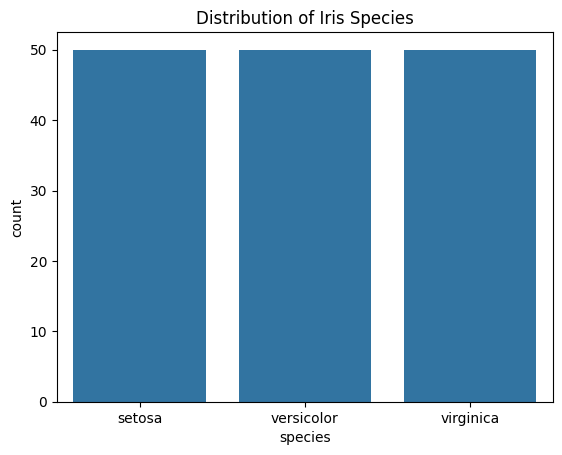

In [7]:
# Create a count plot to visualize the number of samples in each species
# This helps assess class balance in the target variable
# Balanced classes are important for unbiased model training
sns.countplot(data=df, x="species")

# Add a title to make the plot self-explanatory
plt.title("Distribution of Iris Species")

# Display the plot
plt.show()


# 7. Generate Summary Statistics for Numerical Features

In [8]:
# Generate descriptive statistics for all numerical columns in the dataset
# This includes:
# - count: number of non-missing values
# - mean: average value
# - std: standard deviation (spread of the data)
# - min and max: range of values
# - 25%, 50%, 75%: quartiles for understanding distribution
print(df.describe())


       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


# 8. Check for Missing Values in the Dataset

In [9]:
# Check for missing values in each column of the dataset
# isnull() returns a DataFrame of True/False for missing values
# sum() counts the number of True values per column
# This helps confirm data completeness before further analysis
print(df.isnull().sum())


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


# 9. Univariate Analysis: Histograms with KDE for Numerical Features

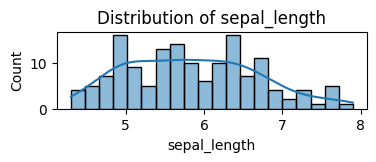

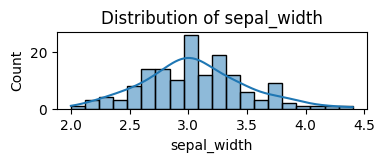

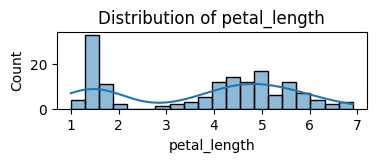

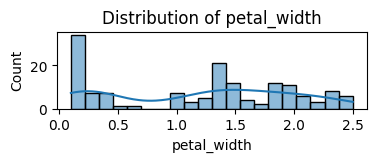

In [10]:
# Select all feature columns (exclude the target label 'species')
features = df.columns[:-1]
# This gives ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Loop through each feature to plot its distribution
for col in features:
    plt.figure(figsize=(4, 1))

    # Plot a histogram with a kernel density estimate (KDE)
    # Histogram shows the frequency distribution
    # KDE gives a smooth estimate of the underlying probability density
    sns.histplot(df[col], bins=20, kde=True)

    # Add a title for clarity
    plt.title(f"Distribution of {col}")

    # Display the plot before moving to the next feature
    plt.show()


# 10. Detect Outliers: Box Plots for Numerical Features

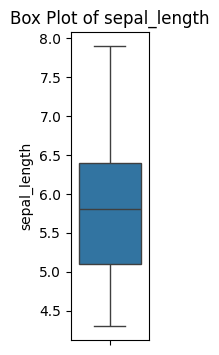

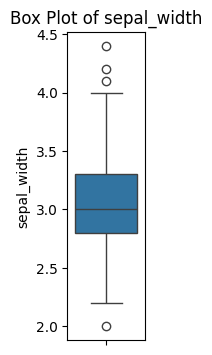

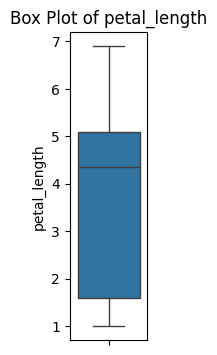

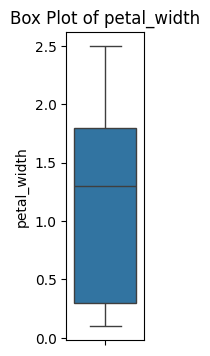

In [11]:
# Loop through each numerical feature to create a box plot
for col in features:
    plt.figure(figsize=(1, 4))

    # Create a box plot for the current feature
    # Box plots summarize:
    # - Median (middle line)
    # - Quartiles (box edges: 25% and 75%)
    # - Whiskers (range excluding outliers)
    # - Outliers (points beyond whiskers)
    sns.boxplot(df[col])

    # Add a title for clarity
    plt.title(f"Box Plot of {col}")

    # Display the plot before moving to the next feature
    plt.show()


# 11. Compare Petal Width Across Species Using Box Plot

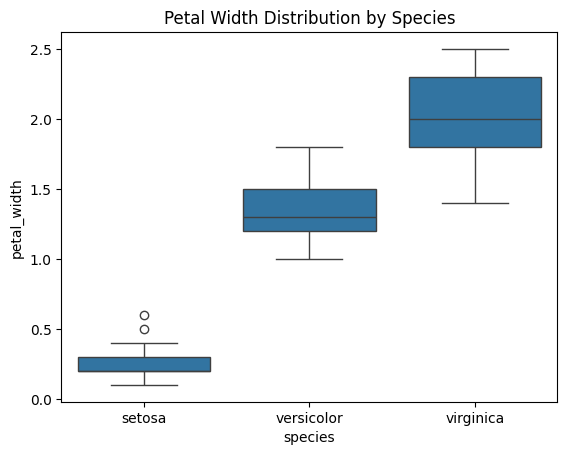

In [12]:
# Create a box plot to compare the distribution of petal width for each species
# - x='species': groups data by species
# - y='petal_width': feature to visualize
# - data=df: source DataFrame
sns.boxplot(x='species', y='petal_width', data=df)

# Add a title for clarity
plt.title("Petal Width Distribution by Species")

# Display the plot
plt.show()


# 12. Visualize Petal Width Distribution by Species Using a Violin Plot

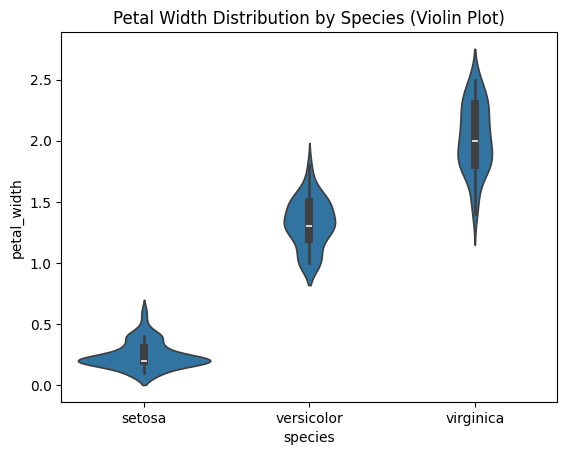

In [13]:
# Create a violin plot to visualize the distribution of petal width for each species
# - x='species': groups data by species
# - y='petal_width': numerical feature to plot
# - data=df: source DataFrame
# Violin plots combine:
#   - Kernel density estimation (distribution shape)
#   - Box plot summary (median, quartiles)
sns.violinplot(x='species', y='petal_width', data=df)

# Add a title for clarity
plt.title("Petal Width Distribution by Species (Violin Plot)")

# Display the plot
plt.show()


# 13. Bivariate Analysis: Pair Plot of Features Colored by Species

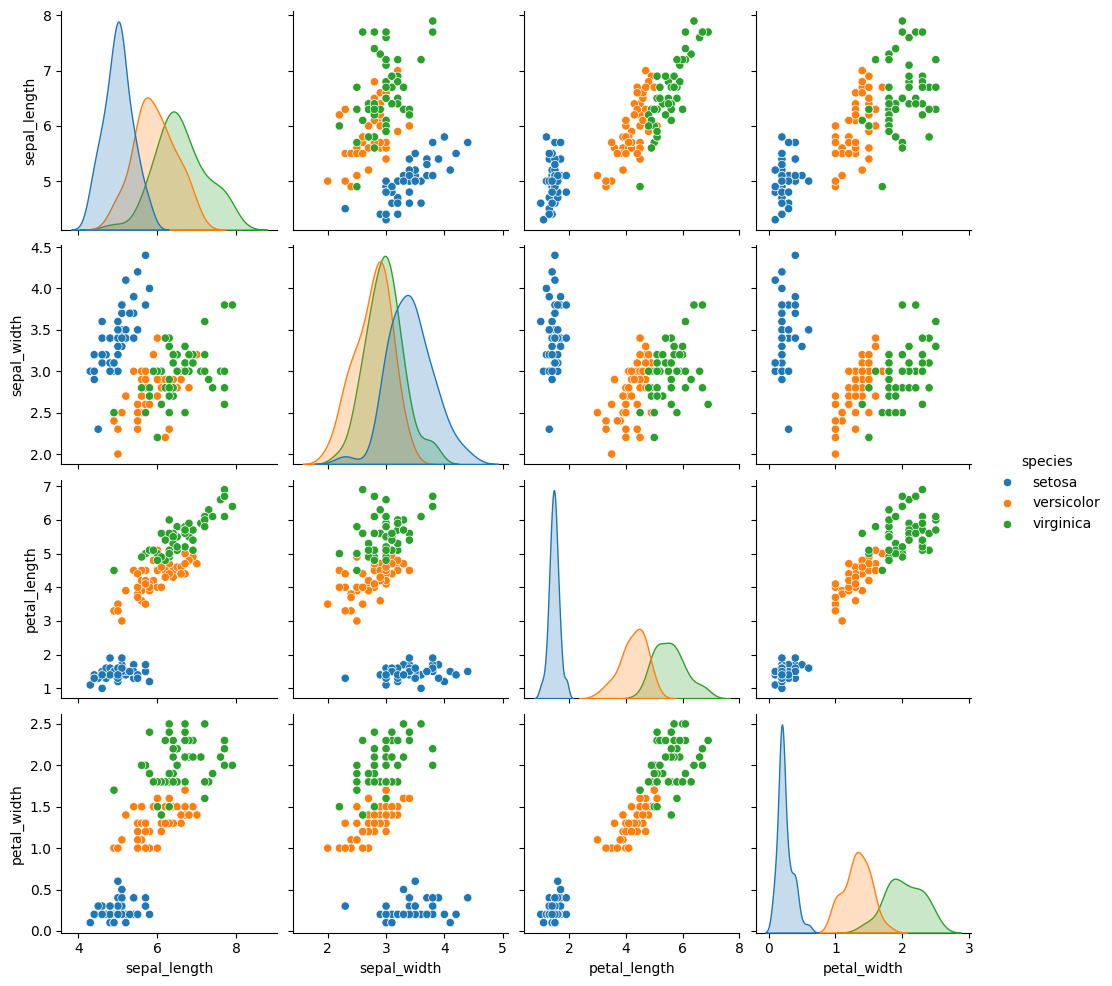

<Figure size 400x400 with 0 Axes>

In [14]:
# Create a pair plot to visualize pairwise relationships between all features
# - df: DataFrame containing features and target
# - hue="species": color points by species for easy class separation
# - diag_kind="kde": show Kernel Density Estimate on the diagonal instead of histograms
# - corner=True: only show lower triangle to avoid redundant plots
sns.pairplot(
    df,
    hue="species",
    diag_kind="kde",
    corner=False
)

# Set figure size (optional, but note: pairplot has its own sizing)
plt.figure(figsize=(4, 4))

# Display the plot
plt.show()


# 14. Correlation Analysis: Heatmap of Feature Relationships

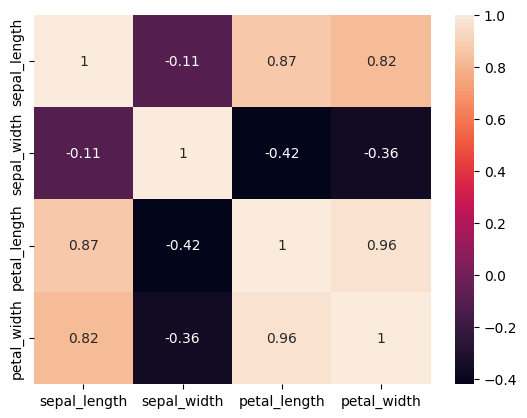

In [15]:
# Compute the correlation matrix for all numerical features
# Correlation values range from -1 to 1
# -> 1: perfect positive correlation
# -> -1: perfect negative correlation
# -> 0: no linear correlation
corr = df[features].corr()

# Create a heatmap to visualize the correlation matrix
# - annot=True: display correlation values on the heatmap
# - cmap can be customized for color (optional)
sns.heatmap(corr, annot=True)

# Display the heatmap
plt.show()
